In [12]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.manifold import TSNE
import kmapper as km
import networkx as nx
from datetime import datetime

# ============================================================
# 1. FEATURE ENGINEERING POR DATASET
# ============================================================

def engineer_client_features(df_clientes, df_productos, df_transacciones, df_conv):
    """
    Construye un vector de características por cliente integrando 
    los 4 datasets. Esta es la unidad de análisis principal.
    """
    feats = df_clientes.copy()
    
    # --- Agregaciones de productos por cliente ---
    prod_agg = df_productos.groupby('user_id').agg(
        n_productos=('producto_id', 'count'),
        saldo_total=('saldo_actual', 'sum'),
        limite_total=('limite_credito', 'sum'),
        utilizacion_promedio=('utilizacion_pct', 'mean'),
        tasa_promedio=('tasa_interes_anual', 'mean'),
        n_productos_activos=('estatus', lambda x: (x == 'activo').sum()),
        diversidad_productos=('tipo_producto', 'nunique')
    ).reset_index()
    
    # --- Agregaciones transaccionales (señales de comportamiento) ---
    tx_agg = df_transacciones.groupby('user_id').agg(
        n_transacciones=('transaccion_id', 'count'),
        monto_total=('monto', 'sum'),
        monto_promedio=('monto', 'mean'),
        monto_std=('monto', 'std'),
        n_canales=('canal', 'nunique'),
        n_categorias=('categoria_mcc', 'nunique'),
        n_ciudades=('ciudad_transaccion', 'nunique'),
        pct_internacional=('es_internacional', 'mean'),
        pct_no_procesadas=('estatus', lambda x: (x != 'exitosa').mean()),
        cashback_total=('cashback_generado', 'sum'),
        atipicidad_tx=('patron_uso_atipico', 'mean'),
        hora_promedio=('hora_del_dia', 'mean'),
        hora_std=('hora_del_dia', 'std')
    ).reset_index()
    
    # --- Señales de conversaciones con chatbot ---
    conv_agg = df_conv.groupby('user_id').agg(
        n_conversaciones=('conv_id', 'nunique'),
        n_mensajes=('input', 'count'),
        long_promedio_input=('input', lambda x: x.str.len().mean()),
        n_canales_chat=('channel_source', 'nunique')
    ).reset_index()
    
    # --- Merge ---
    feats = feats.merge(prod_agg, on='user_id', how='left')
    feats = feats.merge(tx_agg, on='user_id', how='left')
    feats = feats.merge(conv_agg, on='user_id', how='left')
    feats = feats.fillna(0)
    
    return feats


def preprocess_for_mapper(df, categorical_cols, numerical_cols):
    """Codifica categóricas y escala numéricas."""
    X = df.copy()
    
    for col in categorical_cols:
        if col in X.columns:
            X[col] = LabelEncoder().fit_transform(X[col].astype(str))
    
    scaler = StandardScaler()
    X_num = scaler.fit_transform(X[numerical_cols + categorical_cols])
    
    return X_num, scaler


# ============================================================
# 2. SELECCIÓN DE LENS FUNCTIONS
# ============================================================

def build_lenses(X, df):
    print("\n" + "=" * 60)
    print("CONSTRUYENDO LENS FUNCTIONS")
    print("=" * 60)

    lenses = {}
    n = len(df)

    # Lens 1: Riesgo financiero
    if 'utilizacion_promedio' in df.columns and 'score_buro' in df.columns:
        risk = (df['utilizacion_promedio'].fillna(0) -
                df['score_buro'].fillna(df['score_buro'].median()) / 1000)
        lenses['riesgo'] = StandardScaler().fit_transform(risk.values.reshape(-1, 1))
        print("  ✓ Lens 'riesgo'")

    # Lens 2: Engagement
    if 'n_transacciones' in df.columns and 'dias_desde_ultimo_login' in df.columns:
        engagement = (
            np.log1p(df['n_transacciones'].fillna(0)) -
            np.log1p(df['dias_desde_ultimo_login'].fillna(365)) +
            np.log1p(df.get('n_conversaciones', pd.Series(np.zeros(n))).fillna(0))
        )
        lenses['engagement'] = StandardScaler().fit_transform(engagement.values.reshape(-1, 1))
        print("  ✓ Lens 'engagement'")

    # Lens 3: Excentricidad (outliers naturales)
    centroide = X.mean(axis=0)
    excentricidad = np.linalg.norm(X - centroide, axis=1).reshape(-1, 1)
    lenses['excentricidad'] = excentricidad
    print("  ✓ Lens 'excentricidad'")

    # Lens 4: Proyección 2D
    if n < 20000:
        print("  Calculando t-SNE 2D (puede tardar varios minutos)...")
        # Compatibilidad: sklearn >= 1.5 usa max_iter, versiones anteriores usan n_iter
        try:
            lenses['tsne_2d'] = TSNE(n_components=2, perplexity=30,
                                     random_state=42, max_iter=1000).fit_transform(X)
        except TypeError:
            lenses['tsne_2d'] = TSNE(n_components=2, perplexity=30,
                                     random_state=42, n_iter=1000).fit_transform(X)
        print("  ✓ Lens 'tsne_2d'")
    else:
        lenses['pca_2d'] = PCA(n_components=2).fit_transform(X)
        print("  ✓ Lens 'pca_2d' (t-SNE omitido por tamaño)")

    return lenses

# ============================================================
# 3. MAPPER PIPELINE
# ============================================================

def run_mapper(X, lens, n_cubes=15, perc_overlap=0.4, 
               min_cluster_size=5, eps=0.5):
    """
    Construye el grafo Mapper.
    
    Parámetros clave:
    - n_cubes: granularidad. Más cubos = más detalle pero más ruido.
    - perc_overlap: solapamiento entre intervalos. 30-50% es lo típico.
                    Menos = grafo desconectado; más = grafo trivial.
    - min_cluster_size / eps: parámetros DBSCAN para clustering local.
    """
    mapper = km.KeplerMapper(verbose=1)
    
    graph = mapper.map(
        lens=lens,
        X=X,
        cover=km.Cover(n_cubes=n_cubes, perc_overlap=perc_overlap),
        clusterer=DBSCAN(eps=eps, min_samples=min_cluster_size)
    )
    
    return mapper, graph


# ============================================================
# 4. ENRIQUECIMIENTO Y ANÁLISIS DEL GRAFO
# ============================================================

def enrich_graph_with_metadata(graph, df_features, target_cols):
    """
    Para cada nodo del grafo, calcula estadísticas de las variables 
    de interés. Esto es lo que hace el grafo interpretable.
    """
    node_stats = {}
    
    for node_id, member_indices in graph['nodes'].items():
        members = df_features.iloc[member_indices]
        stats = {'size': len(members)}
        
        for col in target_cols:
            if col in members.columns:
                if members[col].dtype in ['float64', 'int64']:
                    stats[f'{col}_mean'] = members[col].mean()
                    stats[f'{col}_std'] = members[col].std()
                else:
                    stats[f'{col}_mode'] = members[col].mode().iloc[0] if len(members[col].mode()) > 0 else None
        
        node_stats[node_id] = stats
    
    return node_stats


def detect_interesting_structures(graph, node_stats):
    """
    Identifica patrones topológicos relevantes:
    - Flares: nodos terminales (segmentos extremos / outliers)
    - Loops: ciclos (comportamientos cíclicos)
    - Bridges: nodos puente entre comunidades
    """
    G = nx.Graph()
    for node, members in graph['nodes'].items():
        G.add_node(node, size=len(members))
    
    for link, neighbors in graph['links'].items():
        for neighbor in neighbors:
            G.add_edge(link, neighbor)
    
    findings = {
        'flares': [n for n in G.nodes() if G.degree(n) == 1],
        'hubs': sorted(G.nodes(), key=lambda n: G.degree(n), reverse=True)[:5],
        'bridges': list(nx.bridges(G)),
        'communities': list(nx.community.greedy_modularity_communities(G)),
        'n_loops': len(nx.cycle_basis(G))
    }
    
    return G, findings


# ============================================================
# 5. PIPELINE COMPLETO
# ============================================================

def full_mapper_pipeline(df_clientes, df_productos, df_transacciones, df_conv):
    # 1. Features integradas a nivel cliente
    feats = engineer_client_features(df_clientes, df_productos, 
                                      df_transacciones, df_conv)
    
    categorical = ['sexo', 'estado', 'nivel_educativo', 'ocupacion', 
                   'canal_apertura', 'preferencia_canal', 'idioma_preferido']
    numerical = ['edad', 'ingreso_mensual_mxn', 'antiguedad_dias', 
                 'score_buro', 'dias_desde_ultimo_login', 'satisfaccion_1_10',
                 'num_productos_activos', 'saldo_total', 'utilizacion_promedio',
                 'n_transacciones', 'monto_promedio', 'pct_internacional',
                 'atipicidad_tx', 'n_conversaciones']
    
    # 2. Preprocesamiento
    X, scaler = preprocess_for_mapper(feats, categorical, numerical)
    
    # 3. Lenses múltiples
    lenses = build_lenses(X, feats)
    
    # 4. Un grafo por lens
    results = {}
    for lens_name, lens_data in lenses.items():
        print(f"\n=== Mapper con lens: {lens_name} ===")
        mapper, graph = run_mapper(X, lens_data, 
                                    n_cubes=15, perc_overlap=0.4)
        
        target_cols = ['edad', 'ingreso_mensual_mxn', 'score_buro',
                       'satisfaccion_1_10', 'utilizacion_promedio',
                       'atipicidad_tx', 'es_hey_pro']
        node_stats = enrich_graph_with_metadata(graph, feats, target_cols)
        G, findings = detect_interesting_structures(graph, node_stats)
        
        # Visualización HTML interactiva
        mapper.visualize(graph, 
                        path_html=f"mapper_{lens_name}.html",
                        title=f"Mapper Bancario - Lens: {lens_name}")
        
        results[lens_name] = {
            'graph': graph,
            'nx_graph': G,
            'node_stats': node_stats,
            'findings': findings
        }
    
    return results, feats

In [ ]:
"""
Pipeline Mapper (TDA) para análisis bancario integrado.
Uso: python mapper_pipeline.py
"""

import os
import sys
import warnings
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.manifold import TSNE
import kmapper as km
import networkx as nx

warnings.filterwarnings('ignore')

# ============================================================
# CONFIGURACIÓN — Ajusta rutas si tu estructura es distinta
# ============================================================

DATA_DIR = "data"
OUTPUT_DIR = "output"

FILES = {
    'clientes':      os.path.join(DATA_DIR, "hey_clientes.csv"),
    'productos':     os.path.join(DATA_DIR, "hey_productos.csv"),
    'transacciones': os.path.join(DATA_DIR, "hey_transacciones.csv"),
    'conversaciones': os.path.join(DATA_DIR, "dataset_50k_anonymized.csv"),
}

os.makedirs(OUTPUT_DIR, exist_ok=True)


# ============================================================
# 1. CARGA DE DATOS
# ============================================================

def load_data():
    print("=" * 60)
    print("CARGANDO DATASETS")
    print("=" * 60)

    dfs = {}
    for name, path in FILES.items():
        if not os.path.exists(path):
            print(f"  ERROR: No se encontró {path}")
            sys.exit(1)
        dfs[name] = pd.read_csv(path)
        print(f"  {name}: {len(dfs[name]):,} filas, {len(dfs[name].columns)} columnas")

    return dfs['clientes'], dfs['productos'], dfs['transacciones'], dfs['conversaciones']


# ============================================================
# 2. FEATURE ENGINEERING POR CLIENTE
# ============================================================

def engineer_client_features(df_clientes, df_productos, df_transacciones, df_conv):
    print("\n" + "=" * 60)
    print("CONSTRUYENDO FEATURES POR CLIENTE")
    print("=" * 60)

    feats = df_clientes.copy()

    # --- Productos ---
    prod_agg = df_productos.groupby('user_id').agg(
        n_productos=('producto_id', 'count'),
        saldo_total=('saldo_actual', 'sum'),
        limite_total=('limite_credito', 'sum'),
        utilizacion_promedio=('utilizacion_pct', 'mean'),
        tasa_promedio=('tasa_interes_anual', 'mean'),
        diversidad_productos=('tipo_producto', 'nunique'),
    ).reset_index()

    # --- Transacciones ---
    tx_agg = df_transacciones.groupby('user_id').agg(
        n_transacciones=('transaccion_id', 'count'),
        monto_total=('monto', 'sum'),
        monto_promedio=('monto', 'mean'),
        monto_std=('monto', 'std'),
        n_canales=('canal', 'nunique'),
        n_categorias=('categoria_mcc', 'nunique'),
        n_ciudades=('ciudad_transaccion', 'nunique'),
        pct_internacional=('es_internacional', 'mean'),
        cashback_total=('cashback_generado', 'sum'),
        atipicidad_tx=('patron_uso_atipico', 'mean'),
        hora_promedio=('hora_del_dia', 'mean'),
        hora_std=('hora_del_dia', 'std'),
    ).reset_index()

    # --- Conversaciones (chatbot) ---
    conv_agg = df_conv.groupby('user_id').agg(
        n_conversaciones=('conv_id', 'nunique'),
        n_mensajes=('input', 'count'),
        long_promedio_input=('input', lambda x: x.astype(str).str.len().mean()),
        n_canales_chat=('channel_source', 'nunique'),
    ).reset_index()

    # --- Merge ---
    feats = feats.merge(prod_agg, on='user_id', how='left')
    feats = feats.merge(tx_agg, on='user_id', how='left')
    feats = feats.merge(conv_agg, on='user_id', how='left')
    feats = feats.fillna(0)

    print(f"  Features finales: {feats.shape[0]:,} clientes x {feats.shape[1]} columnas")
    return feats


# ============================================================
# 3. PREPROCESAMIENTO
# ============================================================

def preprocess_for_mapper(df, categorical_cols, numerical_cols):
    X = df.copy()
    cat_present = [c for c in categorical_cols if c in X.columns]
    num_present = [c for c in numerical_cols if c in X.columns]

    for col in cat_present:
        X[col] = LabelEncoder().fit_transform(X[col].astype(str))

    X_combined = X[num_present + cat_present].values
    X_scaled = StandardScaler().fit_transform(X_combined)

    print(f"  Matriz preprocesada: {X_scaled.shape}")
    return X_scaled, num_present + cat_present


# ============================================================
# 4. LENSES (FILTROS)
# ============================================================

def build_lenses(X, df):
    print("\n" + "=" * 60)
    print("CONSTRUYENDO LENS FUNCTIONS")
    print("=" * 60)

    lenses = {}
    n = len(df)

    # Lens 1: Riesgo financiero
    if 'utilizacion_promedio' in df.columns and 'score_buro' in df.columns:
        risk = (df['utilizacion_promedio'].fillna(0) -
                df['score_buro'].fillna(df['score_buro'].median()) / 1000)
        lenses['riesgo'] = StandardScaler().fit_transform(risk.values.reshape(-1, 1))
        print("  ✓ Lens 'riesgo'")

    # Lens 2: Engagement
    if 'n_transacciones' in df.columns and 'dias_desde_ultimo_login' in df.columns:
        engagement = (
            np.log1p(df['n_transacciones'].fillna(0)) -
            np.log1p(df['dias_desde_ultimo_login'].fillna(365)) +
            np.log1p(df.get('n_conversaciones', pd.Series(np.zeros(n))).fillna(0))
        )
        lenses['engagement'] = StandardScaler().fit_transform(engagement.values.reshape(-1, 1))
        print("  ✓ Lens 'engagement'")

    # Lens 3: Excentricidad (outliers naturales)
    centroide = X.mean(axis=0)
    excentricidad = np.linalg.norm(X - centroide, axis=1).reshape(-1, 1)
    lenses['excentricidad'] = excentricidad
    print("  ✓ Lens 'excentricidad'")

    # Lens 4: Proyección 2D
    if n < 20000:
        print("  Calculando t-SNE 2D (puede tardar varios minutos)...")
        # Compatibilidad: sklearn >= 1.5 usa max_iter, versiones anteriores usan n_iter
        try:
            lenses['tsne_2d'] = TSNE(n_components=2, perplexity=30,
                                     random_state=42, max_iter=1000).fit_transform(X)
        except TypeError:
            lenses['tsne_2d'] = TSNE(n_components=2, perplexity=30,
                                     random_state=42, n_iter=1000).fit_transform(X)
        print("  ✓ Lens 'tsne_2d'")
    else:
        lenses['pca_2d'] = PCA(n_components=2).fit_transform(X)
        print("  ✓ Lens 'pca_2d' (t-SNE omitido por tamaño)")

    return lenses


# ============================================================
# 5. MAPPER
# ============================================================

from sklearn.neighbors import NearestNeighbors

def estimate_eps(X, k=5, percentile=90):
    """
    Estima un eps razonable para DBSCAN usando la distribución
    de distancias al k-ésimo vecino más cercano.
    """
    nn = NearestNeighbors(n_neighbors=k).fit(X)
    distances, _ = nn.kneighbors(X)
    # Usamos un percentil alto de la distancia al k-vecino
    eps = np.percentile(distances[:, -1], percentile)
    return float(eps)


def run_mapper(X, lens, n_cubes=15, perc_overlap=0.4,
               min_cluster_size=3, eps=None):
    """
    Construye el grafo Mapper.
    Si eps=None, lo estima automáticamente desde los datos.
    """
    if eps is None:
        eps = estimate_eps(X, k=min_cluster_size, percentile=90)
        print(f"    eps estimado automáticamente: {eps:.3f}")

    mapper = km.KeplerMapper(verbose=0)
    graph = mapper.map(
        lens=lens,
        X=X,
        cover=km.Cover(n_cubes=n_cubes, perc_overlap=perc_overlap),
        clusterer=DBSCAN(eps=eps, min_samples=min_cluster_size),
    )
    n_nodes = len(graph['nodes'])
    print(f"    Nodos generados: {n_nodes}")

    # Si aún así salieron 0 nodos, reintenta con parámetros más laxos
    if n_nodes == 0:
        print("    ⚠ 0 nodos. Reintentando con eps más grande y min_samples=2...")
        eps_retry = eps * 2
        graph = mapper.map(
            lens=lens,
            X=X,
            cover=km.Cover(n_cubes=n_cubes, perc_overlap=perc_overlap),
            clusterer=DBSCAN(eps=eps_retry, min_samples=2),
        )
        print(f"    Nodos tras reintento: {len(graph['nodes'])}")

    return mapper, graph


# ============================================================
# 6. ANÁLISIS DEL GRAFO
# ============================================================

def analyze_graph(graph, df_features, target_cols, lens_name):
    G = nx.Graph()

    for node, members in graph['nodes'].items():
        members_df = df_features.iloc[members]
        attrs = {'size': len(members)}
        for col in target_cols:
            if col in members_df.columns and members_df[col].dtype in ['float64', 'int64']:
                attrs[f'{col}_mean'] = float(members_df[col].mean())
        G.add_node(node, **attrs)

    for link, neighbors in graph['links'].items():
        for neighbor in neighbors:
            G.add_edge(link, neighbor)

    findings = {
        'n_nodes': G.number_of_nodes(),
        'n_edges': G.number_of_edges(),
        'flares': [n for n in G.nodes() if G.degree(n) == 1],
        'hubs_top5': sorted(G.nodes(), key=lambda n: G.degree(n), reverse=True)[:5],
        'n_components': nx.number_connected_components(G),
        'n_bridges': len(list(nx.bridges(G))) if G.number_of_edges() > 0 else 0,
    }

    print(f"\n  Grafo '{lens_name}':")
    print(f"    Nodos: {findings['n_nodes']}, Aristas: {findings['n_edges']}")
    print(f"    Componentes conexos: {findings['n_components']}")
    print(f"    Flares (ramas terminales): {len(findings['flares'])}")
    print(f"    Bridges (puentes críticos): {findings['n_bridges']}")

    return G, findings


# ============================================================
# 7. PIPELINE COMPLETO
# ============================================================

def main():
    df_clientes, df_productos, df_transacciones, df_conv = load_data()

    feats = engineer_client_features(df_clientes, df_productos,
                                     df_transacciones, df_conv)

    feats.to_csv(os.path.join(OUTPUT_DIR, "client_features.csv"), index=False)
    print(f"\n  Features guardadas en {OUTPUT_DIR}/client_features.csv")

    categorical = ['sexo', 'estado', 'nivel_educativo', 'ocupacion',
                   'canal_apertura', 'preferencia_canal', 'idioma_preferido']
    numerical = ['edad', 'ingreso_mensual_mxn', 'antiguedad_dias',
                 'score_buro', 'dias_desde_ultimo_login', 'satisfaccion_1_10',
                 'num_productos_activos', 'saldo_total', 'utilizacion_promedio',
                 'n_transacciones', 'monto_promedio', 'pct_internacional',
                 'atipicidad_tx', 'n_conversaciones']

    print("\n" + "=" * 60)
    print("PREPROCESAMIENTO")
    print("=" * 60)
    X, used_cols = preprocess_for_mapper(feats, categorical, numerical)

    lenses = build_lenses(X, feats)

    print("\n" + "=" * 60)
    print("EJECUTANDO MAPPER POR CADA LENS")
    print("=" * 60)

    target_cols = ['edad', 'ingreso_mensual_mxn', 'score_buro',
                   'satisfaccion_1_10', 'utilizacion_promedio',
                   'atipicidad_tx']

    summary = {}
    for lens_name, lens_data in lenses.items():
        print(f"\n→ Lens: {lens_name}")
        mapper, graph = run_mapper(X, lens_data,
                                   n_cubes=15, perc_overlap=0.4)

        if len(graph['nodes']) == 0:
            print(f"  ⚠ Lens '{lens_name}' no generó nodos. Saltando visualización.")
            continue

        html_path = os.path.join(OUTPUT_DIR, f"mapper_{lens_name}.html")
        mapper.visualize(graph,
                         path_html=html_path,
                         title=f"Mapper Bancario - {lens_name}")
        print(f"  Visualización: {html_path}")

        G, findings = analyze_graph(graph, feats, target_cols, lens_name)
        summary[lens_name] = findings

        nx.write_gexf(G, os.path.join(OUTPUT_DIR, f"graph_{lens_name}.gexf"))

    print("\n" + "=" * 60)
    print("RESUMEN FINAL")
    print("=" * 60)
    for lens_name, f in summary.items():
        print(f"\n{lens_name}: {f['n_nodes']} nodos, {f['n_edges']} aristas, "
              f"{len(f['flares'])} flares")

    print(f"\n✓ Todos los resultados en: {OUTPUT_DIR}/")
    print("  Abre los .html en el navegador para explorar los grafos interactivamente.")


if __name__ == "__main__":
    main()

usage: ipykernel_launcher.py [-h] [--con-saldos] [--max-users MAX_USERS]
                             [--output OUTPUT]
ipykernel_launcher.py: error: unrecognized arguments: --f=c:\Users\albpa\AppData\Roaming\jupyter\runtime\kernel-v3d058b029b7f34ff7564aea6b6cd9108ddf9a8cc9.json


SystemExit: 2

In [18]:
import os
import sys
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import kmapper as km

# ============================================================
# CARGA Y PREPARACIÓN
# ============================================================

DATA_DIR = "data"

df_clientes = pd.read_csv(os.path.join(DATA_DIR, "hey_clientes.csv"))
df_productos = pd.read_csv(os.path.join(DATA_DIR, "hey_productos.csv"))
df_transacciones = pd.read_csv(os.path.join(DATA_DIR, "hey_transacciones.csv"))
df_conv = pd.read_csv(os.path.join(DATA_DIR, "dataset_50k_anonymized.csv"))

# Si ya guardaste client_features.csv, mejor cárgalo directamente:
feats = pd.read_csv("output/client_features.csv")
print(f"Features cargadas: {feats.shape}")

# ============================================================
# PREPROCESAMIENTO (igual que en el pipeline)
# ============================================================

categorical = ['sexo', 'estado', 'nivel_educativo', 'ocupacion',
               'canal_apertura', 'preferencia_canal', 'idioma_preferido']
numerical = ['edad', 'ingreso_mensual_mxn', 'antiguedad_dias',
             'score_buro', 'dias_desde_ultimo_login', 'satisfaccion_1_10',
             'num_productos_activos', 'saldo_total', 'utilizacion_promedio',
             'n_transacciones', 'monto_promedio', 'pct_internacional',
             'atipicidad_tx', 'n_conversaciones']

cat_present = [c for c in categorical if c in feats.columns]
num_present = [c for c in numerical if c in feats.columns]

X_df = feats.copy()
for col in cat_present:
    X_df[col] = LabelEncoder().fit_transform(X_df[col].astype(str))

X = StandardScaler().fit_transform(X_df[num_present + cat_present].values)
print(f"Matriz X: {X.shape}")

# ============================================================
# LENS ENGAGEMENT
# ============================================================

engagement = (
    np.log1p(feats['n_transacciones'].fillna(0)) -
    np.log1p(feats['dias_desde_ultimo_login'].fillna(365)) +
    np.log1p(feats['n_conversaciones'].fillna(0))
)
lens_engagement = StandardScaler().fit_transform(engagement.values.reshape(-1, 1))

# ============================================================
# MAPPER (con eps automático)
# ============================================================

def estimate_eps(X, k=3, percentile=90):
    nn = NearestNeighbors(n_neighbors=k).fit(X)
    distances, _ = nn.kneighbors(X)
    return float(np.percentile(distances[:, -1], percentile))

eps = estimate_eps(X, k=3, percentile=90)
print(f"eps estimado: {eps:.3f}")

mapper = km.KeplerMapper(verbose=0)
graph_engagement = mapper.map(
    lens=lens_engagement,
    X=X,
    cover=km.Cover(n_cubes=15, perc_overlap=0.4),
    clusterer=DBSCAN(eps=eps, min_samples=3),
)

print(f"✓ Grafo engagement generado: {len(graph_engagement['nodes'])} nodos")

Features cargadas: (15025, 44)
Matriz X: (15025, 21)
eps estimado: 3.026
✓ Grafo engagement generado: 142 nodos


Se detectaron 3 islas principales:
  Isla 1: 51 nodos, ~12844 clientes únicos
  Isla 2: 17 nodos, ~257 clientes únicos
  Isla 3: 14 nodos, ~140 clientes únicos

Tamaño de las islas:
  Isla 1: 12,844 clientes (97.0%)
  Isla 2: 257 clientes (1.9%)
  Isla 3: 140 clientes (1.1%)

Perfil promedio por isla:
                            Isla 1     Isla 2    Isla 3
edad                         36.99      34.11     31.89
ingreso_mensual_mxn       29428.10   26544.75  23985.71
antiguedad_dias             937.41     942.44    918.02
score_buro                  618.35     625.84    613.76
dias_desde_ultimo_login      17.72       6.08      6.29
satisfaccion_1_10             7.24       7.95      7.91
num_productos_activos         2.25       2.23      2.27
saldo_total              138063.30  119398.06  98776.10
utilizacion_promedio          0.31       0.35      0.41
n_transacciones              54.06      62.49     63.04
monto_promedio             5897.36    4917.50   4140.39
pct_internacional        

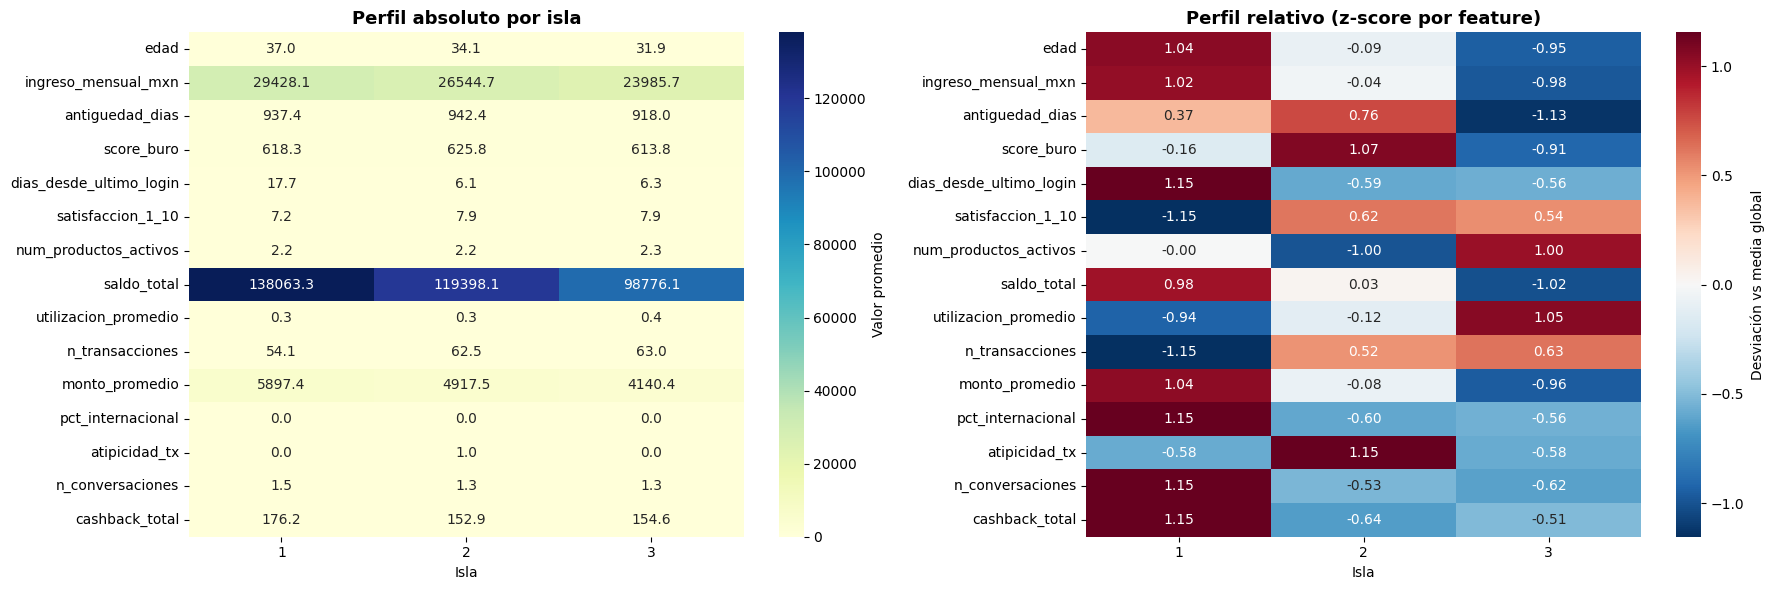


  Heatmap guardado en output/islas_comparacion.png


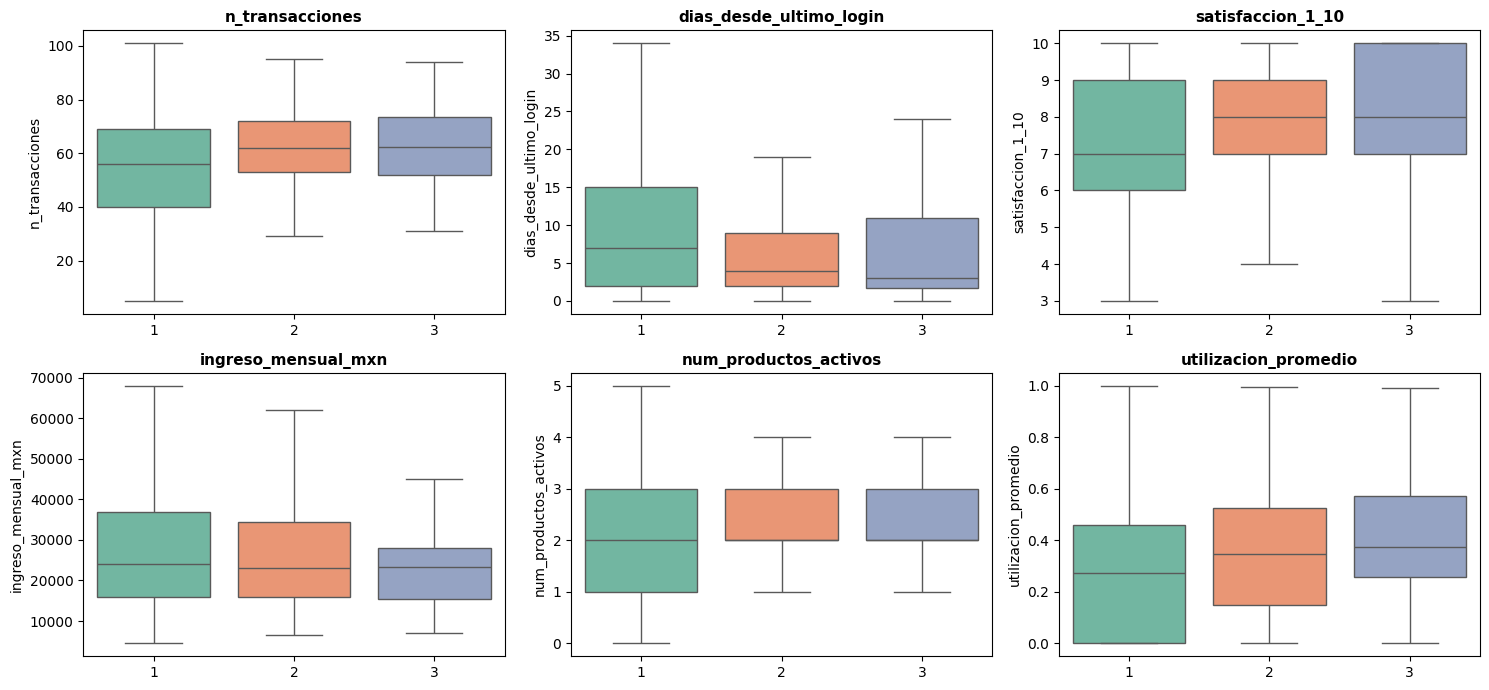

  Boxplots guardados en output/islas_distribuciones.png

CARACTERIZACIÓN AUTOMÁTICA DE ISLAS

🏝️  ISLA 1
   ↑ DESTACA EN (vs otras islas):
      • dias_desde_ultimo_login: +1.15 σ
      • pct_internacional: +1.15 σ
      • n_conversaciones: +1.15 σ
   ↓ DEFICIENTE EN:
      • satisfaccion_1_10: -1.15 σ
      • n_transacciones: -1.15 σ
      • utilizacion_promedio: -0.94 σ
   → ETIQUETA: 😴 DURMIENTES — Sin actividad reciente

🏝️  ISLA 2
   ↑ DESTACA EN (vs otras islas):
      • atipicidad_tx: +1.15 σ
      • score_buro: +1.07 σ
      • antiguedad_dias: +0.76 σ
   ↓ DEFICIENTE EN:
      • num_productos_activos: -1.00 σ
      • cashback_total: -0.64 σ
      • pct_internacional: -0.60 σ
   → ETIQUETA: 💎 POWER USERS — Alta actividad y reciente

🏝️  ISLA 3
   ↑ DESTACA EN (vs otras islas):
      • utilizacion_promedio: +1.05 σ
      • num_productos_activos: +1.00 σ
      • n_transacciones: +0.63 σ
   ↓ DEFICIENTE EN:
      • antiguedad_dias: -1.13 σ
      • saldo_total: -1.02 σ
      • ingre

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from sklearn.preprocessing import StandardScaler

# ============================================================
# ANÁLISIS DE LAS 3 ISLAS DEL MAPPER (lens: engagement)
# ============================================================

def identify_islands(graph, df_features, min_island_size=5):
    """
    Identifica componentes conexos del grafo Mapper y asigna cada
    cliente a una isla según los nodos a los que pertenece.
    """
    # 1. Reconstruir grafo de NetworkX
    G = nx.Graph()
    for node in graph['nodes']:
        G.add_node(node)
    for link, neighbors in graph['links'].items():
        for neighbor in neighbors:
            G.add_edge(link, neighbor)

    # 2. Componentes conexos ordenados por tamaño
    components = sorted(nx.connected_components(G), key=len, reverse=True)
    components = [c for c in components if len(c) >= min_island_size]

    print(f"Se detectaron {len(components)} islas principales:")
    for i, comp in enumerate(components):
        n_clientes = len(set().union(*[graph['nodes'][n] for n in comp]))
        print(f"  Isla {i+1}: {len(comp)} nodos, ~{n_clientes} clientes únicos")

    # 3. Asignar cada cliente a una isla (la mayoritaria si está en varias)
    cliente_a_isla = {}
    for i, comp in enumerate(components):
        for node in comp:
            for cliente_idx in graph['nodes'][node]:
                # Si ya está asignado, queda en la primera (la más grande)
                if cliente_idx not in cliente_a_isla:
                    cliente_a_isla[cliente_idx] = i + 1

    df_labeled = df_features.copy()
    df_labeled['isla'] = df_labeled.index.map(cliente_a_isla)
    df_labeled = df_labeled.dropna(subset=['isla'])
    df_labeled['isla'] = df_labeled['isla'].astype(int)

    return df_labeled, components


def profile_islands(df_labeled, key_features):
    """Calcula el perfil estadístico de cada isla."""
    profile = df_labeled.groupby('isla')[key_features].mean().T
    profile.columns = [f'Isla {c}' for c in profile.columns]

    # Tamaño de cada isla
    sizes = df_labeled['isla'].value_counts().sort_index()
    print("\nTamaño de las islas:")
    for isla, size in sizes.items():
        pct = 100 * size / len(df_labeled)
        print(f"  Isla {isla}: {size:,} clientes ({pct:.1f}%)")

    return profile


def plot_island_comparison(df_labeled, key_features, output_path='output/islas_comparacion.png'):
    """
    Heatmap normalizado: cada feature se z-score por columna,
    para ver qué isla destaca en qué dimensión.
    """
    profile = df_labeled.groupby('isla')[key_features].mean()

    # Normalizar por columna (z-score) para comparar islas relativamente
    profile_z = (profile - profile.mean()) / profile.std()

    fig, axes = plt.subplots(1, 2, figsize=(18, max(6, len(key_features) * 0.4)))

    # --- Heatmap de valores absolutos ---
    sns.heatmap(profile.T, annot=True, fmt='.1f', cmap='YlGnBu',
                ax=axes[0], cbar_kws={'label': 'Valor promedio'})
    axes[0].set_title('Perfil absoluto por isla', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Isla')
    axes[0].set_ylabel('')

    # --- Heatmap normalizado (z-score) ---
    sns.heatmap(profile_z.T, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                ax=axes[1], cbar_kws={'label': 'Desviación vs media global'})
    axes[1].set_title('Perfil relativo (z-score por feature)', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Isla')
    axes[1].set_ylabel('')

    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\n  Heatmap guardado en {output_path}")


def plot_island_distributions(df_labeled, features_to_plot,
                               output_path='output/islas_distribuciones.png'):
    """Boxplots por isla para entender distribuciones, no solo promedios."""
    n_features = len(features_to_plot)
    n_cols = 3
    n_rows = (n_features + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3.5))
    axes = axes.flatten() if n_features > 1 else [axes]

    palette = sns.color_palette('Set2', df_labeled['isla'].nunique())

    for i, feat in enumerate(features_to_plot):
        if feat in df_labeled.columns:
            sns.boxplot(data=df_labeled, x='isla', y=feat,
                        ax=axes[i], palette=palette, showfliers=False)
            axes[i].set_title(feat, fontsize=11, fontweight='bold')
            axes[i].set_xlabel('')

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Boxplots guardados en {output_path}")


def auto_label_islands(df_labeled, key_features):
    """
    Genera etiquetas automáticas describiendo cada isla
    en función de qué features son altas/bajas vs el promedio.
    """
    profile = df_labeled.groupby('isla')[key_features].mean()
    profile_z = (profile - profile.mean()) / profile.std()

    print("\n" + "=" * 60)
    print("CARACTERIZACIÓN AUTOMÁTICA DE ISLAS")
    print("=" * 60)

    labels = {}
    for isla in profile_z.index:
        row = profile_z.loc[isla].sort_values()
        bajas = row.head(3)
        altas = row.tail(3)[::-1]

        print(f"\n🏝️  ISLA {isla}")
        print(f"   ↑ DESTACA EN (vs otras islas):")
        for feat, val in altas.items():
            print(f"      • {feat}: {val:+.2f} σ")
        print(f"   ↓ DEFICIENTE EN:")
        for feat, val in bajas.items():
            print(f"      • {feat}: {val:+.2f} σ")

        # Etiqueta heurística simple
        n_tx = profile.loc[isla].get('n_transacciones', 0)
        login = profile.loc[isla].get('dias_desde_ultimo_login', 0)
        n_prods = profile.loc[isla].get('num_productos_activos', 0)

        if n_tx > profile['n_transacciones'].mean() and login < profile['dias_desde_ultimo_login'].mean():
            label = "💎 POWER USERS — Alta actividad y reciente"
        elif login > profile['dias_desde_ultimo_login'].mean() * 1.5:
            label = "😴 DURMIENTES — Sin actividad reciente"
        elif n_prods > profile['num_productos_activos'].mean():
            label = "🌱 MULTI-PRODUCTO — Buen cross-sell, engagement medio"
        else:
            label = "📊 USUARIOS PROMEDIO — Comportamiento estándar"

        labels[isla] = label
        print(f"   → ETIQUETA: {label}")

    return labels


# ============================================================
# EJECUCIÓN
# ============================================================

# Asume que ya corriste main() y tienes 'summary' + 'feats' en memoria.
# Si no, recupera el grafo de engagement directamente:

# Necesitas el dict 'graph' del lens engagement. Si lo perdiste, vuelve a correr:
#   mapper, graph_engagement = run_mapper(X, lenses['engagement'])
# Aquí asumo que tienes 'graph_engagement' disponible.

# Variables clave para perfilar (las del feature engineering)
KEY_FEATURES = [
    'edad', 'ingreso_mensual_mxn', 'antiguedad_dias', 'score_buro',
    'dias_desde_ultimo_login', 'satisfaccion_1_10',
    'num_productos_activos', 'saldo_total', 'utilizacion_promedio',
    'n_transacciones', 'monto_promedio', 'pct_internacional',
    'atipicidad_tx', 'n_conversaciones', 'cashback_total'
]
KEY_FEATURES = [f for f in KEY_FEATURES if f in feats.columns]

# 1. Identificar islas
df_labeled, components = identify_islands(graph_engagement, feats, min_island_size=5)

# 2. Perfil estadístico
profile = profile_islands(df_labeled, KEY_FEATURES)
print("\nPerfil promedio por isla:")
print(profile.round(2))

# 3. Visualizaciones
plot_island_comparison(df_labeled, KEY_FEATURES)
plot_island_distributions(df_labeled, [
    'n_transacciones', 'dias_desde_ultimo_login', 'satisfaccion_1_10',
    'ingreso_mensual_mxn', 'num_productos_activos', 'utilizacion_promedio'
])

# 4. Etiquetado automático
labels = auto_label_islands(df_labeled, KEY_FEATURES)

# 5. Guardar tabla de clientes etiquetados (útil para acción posterior)
df_labeled[['user_id', 'isla'] + KEY_FEATURES].to_csv(
    'output/clientes_por_isla.csv', index=False
)
print("\n✓ Asignación de clientes guardada en output/clientes_por_isla.csv")

Clientes: 15,025
Varianza explicada: 65.38%

BÚSQUEDA DE K ÓPTIMO
  K=2: inertia=191641, silhouette=0.198, DB=1.729
  K=3: inertia=160013, silhouette=0.216, DB=1.621
  K=4: inertia=147956, silhouette=0.184, DB=1.823
  K=5: inertia=139749, silhouette=0.148, DB=1.910
  K=6: inertia=133706, silhouette=0.143, DB=1.939
  K=7: inertia=129147, silhouette=0.133, DB=2.156
  K=8: inertia=123865, silhouette=0.131, DB=2.038
  K=9: inertia=121281, silhouette=0.125, DB=2.069
  K=10: inertia=114640, silhouette=0.140, DB=1.920


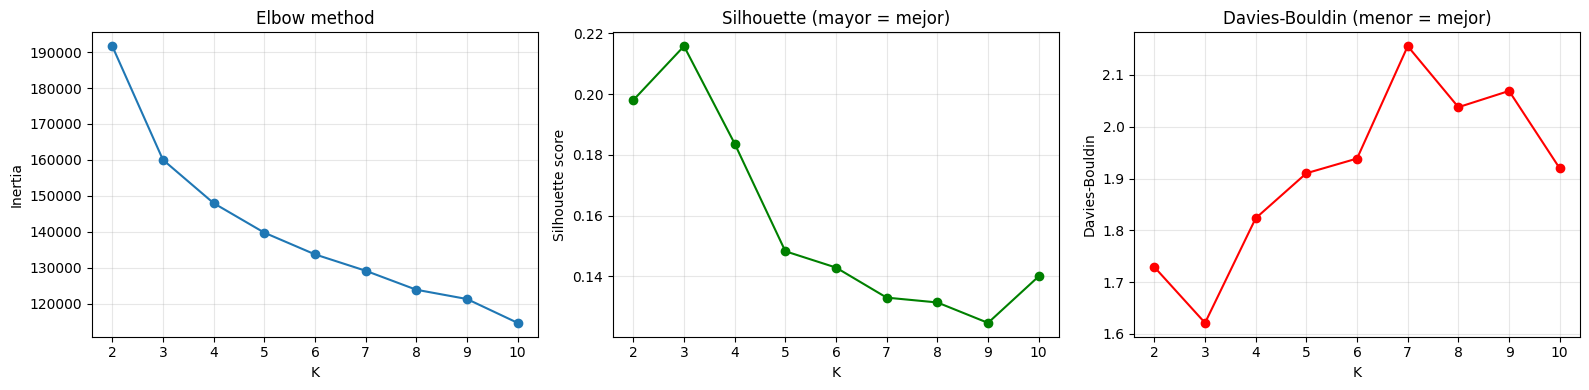


✓ K óptimo según silhouette: 3

✓ Clustering con K=3
  Cluster 0: 2,293 clientes (15.3%)
  Cluster 1: 7,052 clientes (46.9%)
  Cluster 2: 5,680 clientes (37.8%)


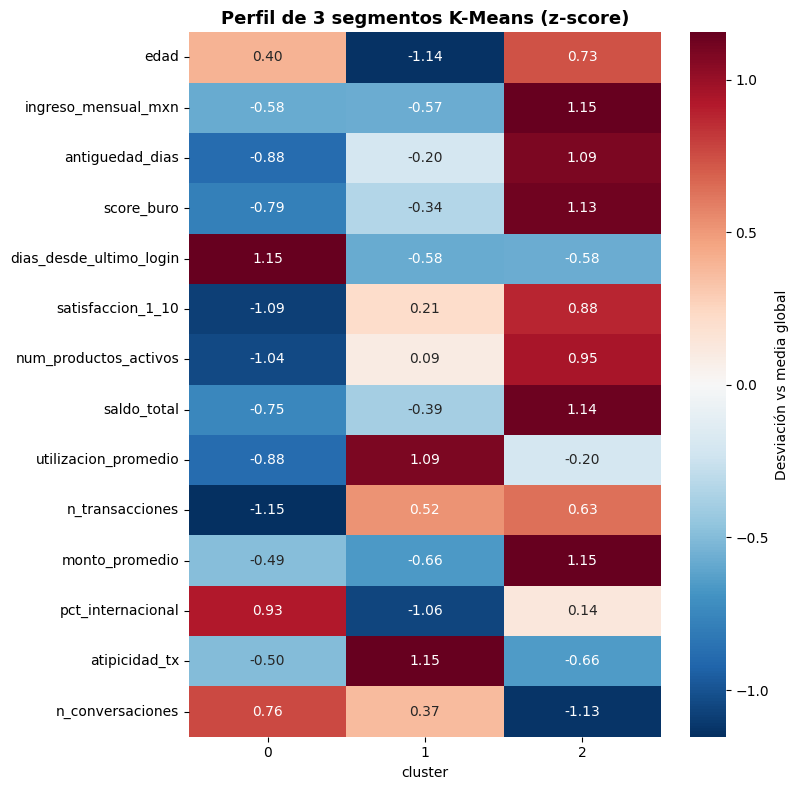


Calculando t-SNE 2D...


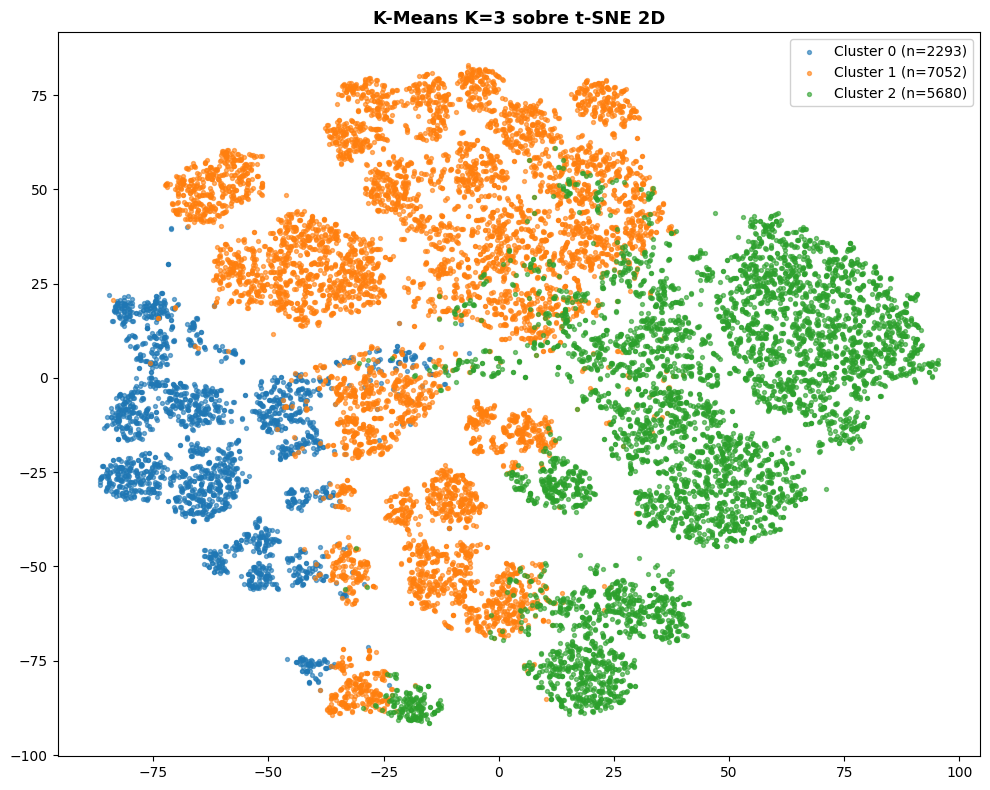

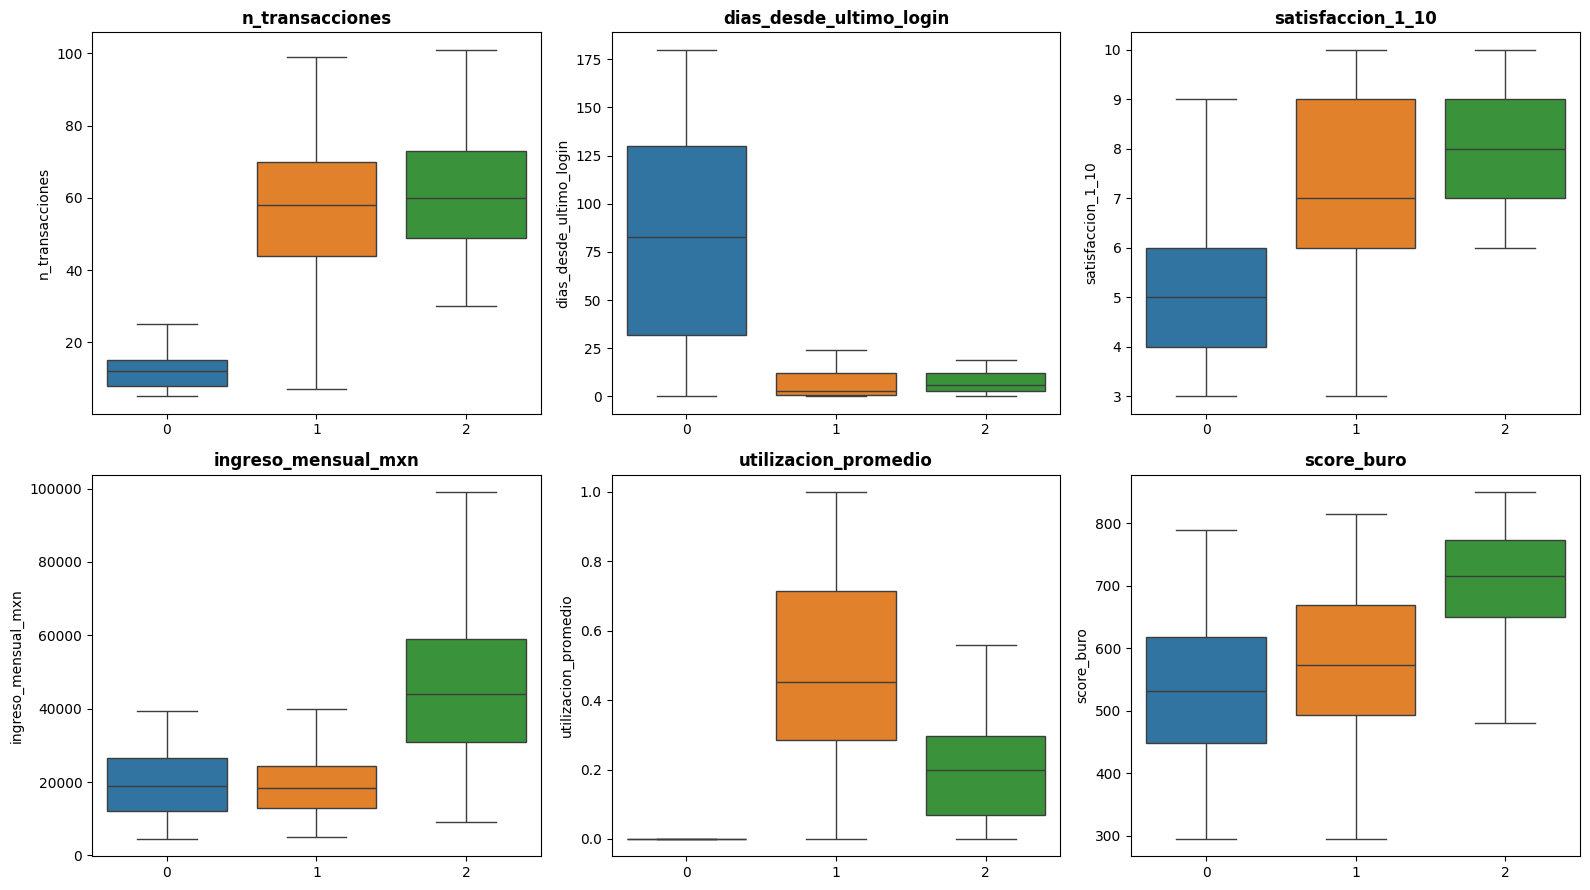


CARACTERIZACIÓN DE SEGMENTOS

🎯 SEGMENTO 0 — 2,293 clientes (15.3%)
   ↑ DESTACA EN:
      • dias_desde_ultimo_login: 83.2 (z=+1.15)
      • pct_internacional: 0.1 (z=+0.93)
      • n_conversaciones: 1.6 (z=+0.76)
   ↓ DEFICIENTE EN:
      • n_transacciones: 18.4 (z=-1.15)
      • satisfaccion_1_10: 5.2 (z=-1.09)
      • num_productos_activos: 0.8 (z=-1.04)

🎯 SEGMENTO 1 — 7,052 clientes (46.9%)
   ↑ DESTACA EN:
      • atipicidad_tx: 0.1 (z=+1.15)
      • utilizacion_promedio: 0.5 (z=+1.09)
      • n_transacciones: 58.5 (z=+0.52)
   ↓ DEFICIENTE EN:
      • edad: 32.9 (z=-1.14)
      • pct_internacional: 0.0 (z=-1.06)
      • monto_promedio: 3663.1 (z=-0.66)

🎯 SEGMENTO 2 — 5,680 clientes (37.8%)
   ↑ DESTACA EN:
      • ingreso_mensual_mxn: 46703.3 (z=+1.15)
      • monto_promedio: 9576.1 (z=+1.15)
      • saldo_total: 251644.0 (z=+1.14)
   ↓ DEFICIENTE EN:
      • n_conversaciones: 1.6 (z=-1.13)
      • atipicidad_tx: 0.0 (z=-0.66)
      • dias_desde_ultimo_login: 7.3 (z=-0.58)

✓ 

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

# ============================================================
# 1. CARGA Y PREPROCESAMIENTO (igual que antes)
# ============================================================

feats = pd.read_csv("output/client_features.csv")
print(f"Clientes: {feats.shape[0]:,}")

categorical = ['sexo', 'estado', 'nivel_educativo', 'ocupacion',
               'canal_apertura', 'preferencia_canal', 'idioma_preferido']
numerical = ['edad', 'ingreso_mensual_mxn', 'antiguedad_dias', 'score_buro',
             'dias_desde_ultimo_login', 'satisfaccion_1_10',
             'num_productos_activos', 'saldo_total', 'utilizacion_promedio',
             'tasa_promedio', 'n_transacciones', 'monto_promedio',
             'monto_std', 'pct_internacional', 'cashback_total',
             'atipicidad_tx', 'n_conversaciones', 'diversidad_productos']

cat_present = [c for c in categorical if c in feats.columns]
num_present = [c for c in numerical if c in feats.columns]

X_df = feats.copy()
for col in cat_present:
    X_df[col] = LabelEncoder().fit_transform(X_df[col].astype(str))

skewed = ['ingreso_mensual_mxn', 'saldo_total', 'monto_promedio',
          'cashback_total', 'n_transacciones']
for col in skewed:
    if col in X_df.columns:
        X_df[col] = np.log1p(X_df[col].clip(lower=0))

X = StandardScaler().fit_transform(X_df[num_present + cat_present].values)

pca = PCA(n_components=10, random_state=42)
X_reduced = pca.fit_transform(X)
print(f"Varianza explicada: {pca.explained_variance_ratio_.sum():.2%}")

# ============================================================
# 2. ELEGIR K CON ELBOW + SILHOUETTE
# ============================================================

print("\n" + "=" * 60)
print("BÚSQUEDA DE K ÓPTIMO")
print("=" * 60)

k_range = range(2, 11)
inertias = []
silhouettes = []
db_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_reduced)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_reduced, labels, sample_size=5000, random_state=42)
    db = davies_bouldin_score(X_reduced, labels)
    silhouettes.append(sil)
    db_scores.append(db)
    print(f"  K={k}: inertia={km.inertia_:.0f}, silhouette={sil:.3f}, DB={db:.3f}")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(list(k_range), inertias, 'o-')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow method'); axes[0].grid(alpha=0.3)

axes[1].plot(list(k_range), silhouettes, 'o-', color='green')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette (mayor = mejor)'); axes[1].grid(alpha=0.3)

axes[2].plot(list(k_range), db_scores, 'o-', color='red')
axes[2].set_xlabel('K'); axes[2].set_ylabel('Davies-Bouldin')
axes[2].set_title('Davies-Bouldin (menor = mejor)'); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('output/kmeans_seleccion_k.png', dpi=150, bbox_inches='tight')
plt.show()

# Elegir K con mejor silhouette
best_k = list(k_range)[np.argmax(silhouettes)]
print(f"\n✓ K óptimo según silhouette: {best_k}")

# ============================================================
# 3. CLUSTERING FINAL
# ============================================================

K = best_k  # puedes cambiarlo manualmente si prefieres otro (ej: K=5 para storytelling)

kmeans = KMeans(n_clusters=K, random_state=42, n_init=20)
labels = kmeans.fit_predict(X_reduced)
feats['cluster'] = labels

print(f"\n✓ Clustering con K={K}")
sizes = feats['cluster'].value_counts().sort_index()
for cid, size in sizes.items():
    print(f"  Cluster {cid}: {size:,} clientes ({100*size/len(feats):.1f}%)")

# ============================================================
# 4. PERFIL Y VISUALIZACIONES
# ============================================================

KEY_FEATURES = ['edad', 'ingreso_mensual_mxn', 'antiguedad_dias', 'score_buro',
                'dias_desde_ultimo_login', 'satisfaccion_1_10',
                'num_productos_activos', 'saldo_total', 'utilizacion_promedio',
                'n_transacciones', 'monto_promedio', 'pct_internacional',
                'atipicidad_tx', 'n_conversaciones']
KEY_FEATURES = [f for f in KEY_FEATURES if f in feats.columns]

profile = feats.groupby('cluster')[KEY_FEATURES].mean()
profile_z = (profile - profile.mean()) / profile.std().replace(0, 1)

# Heatmap
fig, ax = plt.subplots(figsize=(max(8, K * 1.5), 8))
sns.heatmap(profile_z.T, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            cbar_kws={'label': 'Desviación vs media global'}, ax=ax)
ax.set_title(f'Perfil de {K} segmentos K-Means (z-score)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('output/kmeans_perfil.png', dpi=150, bbox_inches='tight')
plt.show()

# t-SNE
print("\nCalculando t-SNE 2D...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_2d = tsne.fit_transform(X_reduced)

fig, ax = plt.subplots(figsize=(10, 8))
palette = sns.color_palette('tab10', K)
for cid in range(K):
    mask = labels == cid
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], c=[palette[cid]],
               s=8, alpha=0.6, label=f'Cluster {cid} (n={mask.sum()})')
ax.set_title(f'K-Means K={K} sobre t-SNE 2D', fontsize=13, fontweight='bold')
ax.legend(loc='best', framealpha=0.9)
plt.tight_layout()
plt.savefig('output/kmeans_proyeccion.png', dpi=150, bbox_inches='tight')
plt.show()

# Boxplots
features_box = ['n_transacciones', 'dias_desde_ultimo_login',
                'satisfaccion_1_10', 'ingreso_mensual_mxn',
                'utilizacion_promedio', 'score_buro']
features_box = [f for f in features_box if f in feats.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for i, feat in enumerate(features_box):
    ax = axes[i // 3, i % 3]
    sns.boxplot(data=feats, x='cluster', y=feat, ax=ax,
                palette='tab10', showfliers=False)
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel('')
plt.tight_layout()
plt.savefig('output/kmeans_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 5. CARACTERIZACIÓN AUTOMÁTICA
# ============================================================

print("\n" + "=" * 60)
print("CARACTERIZACIÓN DE SEGMENTOS")
print("=" * 60)

for cid in sorted(profile.index):
    row_z = profile_z.loc[cid].sort_values()
    altas = row_z.tail(3)[::-1]
    bajas = row_z.head(3)
    n = (feats['cluster'] == cid).sum()

    print(f"\n🎯 SEGMENTO {cid} — {n:,} clientes ({100*n/len(feats):.1f}%)")
    print(f"   ↑ DESTACA EN:")
    for feat, val in altas.items():
        print(f"      • {feat}: {profile.loc[cid, feat]:.1f} (z={val:+.2f})")
    print(f"   ↓ DEFICIENTE EN:")
    for feat, val in bajas.items():
        print(f"      • {feat}: {profile.loc[cid, feat]:.1f} (z={val:+.2f})")

# ============================================================
# 6. EXPORTAR
# ============================================================

feats[['user_id', 'cluster'] + KEY_FEATURES].to_csv(
    'output/clientes_segmentados_kmeans.csv', index=False
)
print("\n✓ Guardado en output/clientes_segmentados_kmeans.csv")

In [54]:
"""
Avisos Engine - Hey Banco
=========================
Pipeline de 5 pasos sobre hey_transacciones.csv que genera avisos_output.json
con alertas y reportes por usuario.

Paso 1: Detectar recurrencias        (mismo comercio + monto similar + 3+ veces)
Paso 2: Suscripciones que subieron   (cargo_recurrente, mes vs mes anterior, +$10)
Paso 3: Cashflow forecast 30 días    (ingresos vs gastos promedio últimos 3 meses)
Paso 4: Gasto anómalo personal       (categoria_mcc, media + 1.5*std en 6 meses)
Paso 5: Reporte de bloques           (ranking por categoría + regaño del mes)

Archivos requeridos en data/:
    hey_transacciones.csv   — transacciones bancarias
    hey_clientes.csv        — columnas usadas: user_id, ingreso_mensual_mxn

Uso en Jupyter:
    main()
    main(max_users=100)

Uso en terminal:
    python avisos_engine.py
    python avisos_engine.py --max-users 100

Dependencias: pandas, numpy
"""

from __future__ import annotations

import json
import math
import os
import sys
from datetime import timedelta
from pathlib import Path

import numpy as np
import pandas as pd


# ---------------------------------------------------------------------------
# Rutas
# ---------------------------------------------------------------------------
BASE_DIR   = Path(os.path.abspath(""))
DATA_DIR   = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "output"

FILES = {
    "transacciones": DATA_DIR / "hey_transacciones.csv",
    "clientes":      DATA_DIR / "hey_clientes.csv",
}

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# ---------------------------------------------------------------------------
# Catálogo de tipos de operación
# ---------------------------------------------------------------------------
OUTFLOWS = {
    "compra", "transf_salida", "retiro_cajero",
    "pago_servicio", "pago_credito", "abono_inversion", "cargo_recurrente",
}
INFLOWS = {
    "transf_entrada", "deposito_oxxo", "deposito_farmacia",
    "retiro_inversion", "cashback", "devolucion",
}
INGRESOS_FORECAST = {"transf_entrada", "deposito_oxxo", "deposito_farmacia"}
GASTOS_FORECAST   = {"compra", "transf_salida", "cargo_recurrente", "pago_servicio", "pago_credito"}


# ---------------------------------------------------------------------------
# Carga de datos
# ---------------------------------------------------------------------------
def load_data() -> tuple[pd.DataFrame, dict]:
    print("=" * 60)
    print("CARGANDO DATASETS")
    print("=" * 60)

    for nombre, path in FILES.items():
        if not path.exists():
            print(f"\n  ERROR: No se encontró '{nombre}'")
            print(f"         Ruta esperada: {path}")
            sys.exit(1)

    txn      = _load_transacciones(FILES["transacciones"])
    ingresos = _load_ingresos(FILES["clientes"])

    print(f"  clientes        : {len(ingresos):,} usuarios con ingreso_mensual_mxn")
    print("=" * 60)
    return txn, ingresos


def _load_transacciones(path: Path) -> pd.DataFrame:
    raw = pd.read_csv(path, encoding="utf-8-sig", low_memory=False)
    n0  = len(raw)

    df = raw[raw["motivo_no_procesada"].isna()].copy()
    print(f"  transacciones   : {n0:,} filas totales → {len(df):,} exitosas")

    df["fecha_hora"]     = pd.to_datetime(df["fecha_hora"], errors="coerce")
    df                   = df.dropna(subset=["fecha_hora", "user_id", "monto", "tipo_operacion"])
    df["tipo_operacion"] = df["tipo_operacion"].astype(str).str.lower().str.strip()

    monto_abs          = df["monto"].abs()
    is_in              = df["tipo_operacion"].isin(INFLOWS)
    df["monto_signed"] = np.where(is_in, monto_abs, -monto_abs)
    df["monto_abs"]    = monto_abs
    df["mes"]          = df["fecha_hora"].dt.to_period("M")

    return df


def _load_ingresos(path: Path) -> dict:
    """Retorna {user_id: ingreso_mensual_mxn} desde hey_clientes.csv."""
    df = pd.read_csv(path, usecols=["user_id", "ingreso_mensual_mxn"])
    df = df.dropna(subset=["user_id", "ingreso_mensual_mxn"])
    return dict(zip(df["user_id"], df["ingreso_mensual_mxn"].astype(float)))


# ---------------------------------------------------------------------------
# PASO 1: Recurrencias
# ---------------------------------------------------------------------------
def detectar_recurrencias(user_txn: pd.DataFrame) -> list[dict]:
    """Mismo comercio + monto +-10% + 3 o más ocurrencias."""
    if user_txn.empty or "comercio_nombre" not in user_txn.columns:
        return []

    elegibles = user_txn[user_txn["tipo_operacion"].isin(OUTFLOWS)].copy()
    elegibles = elegibles.dropna(subset=["comercio_nombre"])
    if elegibles.empty:
        return []

    grouped = elegibles.groupby("comercio_nombre").agg(
        n_veces        = ("transaccion_id", "count"),
        monto_promedio = ("monto_abs", "mean"),
        monto_std      = ("monto_abs", "std"),
        dia_tipico     = ("dia_semana",    lambda x: x.mode().iloc[0] if not x.mode().empty else None),
        hora_tipica    = ("hora_del_dia",  lambda x: int(x.mode().iloc[0]) if not x.mode().empty else None),
        categoria      = ("categoria_mcc", lambda x: x.mode().iloc[0] if not x.mode().empty else None),
        ultima_fecha   = ("fecha_hora", "max"),
    ).reset_index()

    grouped["monto_std"] = grouped["monto_std"].fillna(0.0)
    grouped["coef_var"]  = grouped["monto_std"] / grouped["monto_promedio"].replace(0, np.nan)

    recurrentes = grouped[
        (grouped["n_veces"] >= 3) & (grouped["coef_var"].fillna(0) < 0.10)
    ].sort_values("monto_promedio", ascending=False)

    return [
        {
            "comercio":       r["comercio_nombre"],
            "categoria_mcc":  r["categoria"],
            "n_veces":        int(r["n_veces"]),
            "monto_promedio": round(float(r["monto_promedio"]), 2),
            "dia_tipico":     r["dia_tipico"],
            "hora_tipica":    r["hora_tipica"],
            "ultima_fecha":   r["ultima_fecha"].isoformat() if pd.notna(r["ultima_fecha"]) else None,
        }
        for _, r in recurrentes.iterrows()
    ]


# ---------------------------------------------------------------------------
# PASO 2: Suscripciones que subieron
# ---------------------------------------------------------------------------
def detectar_suscripciones_subieron(user_txn: pd.DataFrame, umbral_mxn: float = 10.0) -> list[dict]:
    """Alerta si un cargo_recurrente subió más de umbral_mxn entre meses contiguos."""
    cargos = user_txn[user_txn["tipo_operacion"] == "cargo_recurrente"].copy()
    cargos = cargos.dropna(subset=["comercio_nombre"])
    if cargos.empty:
        return []

    por_mes = (
        cargos.groupby(["comercio_nombre", "mes"])["monto_abs"]
        .mean().reset_index()
        .sort_values(["comercio_nombre", "mes"])
    )

    alertas = []
    for comercio, sub in por_mes.groupby("comercio_nombre"):
        if len(sub) < 2:
            continue
        ultimo, prev = sub.iloc[-1], sub.iloc[-2]
        if (ultimo["mes"] - prev["mes"]).n != 1:
            continue
        delta = float(ultimo["monto_abs"]) - float(prev["monto_abs"])
        if delta > umbral_mxn:
            alertas.append({
                "comercio":       comercio,
                "monto_anterior": round(float(prev["monto_abs"]), 2),
                "monto_actual":   round(float(ultimo["monto_abs"]), 2),
                "incremento_mxn": round(delta, 2),
                "incremento_pct": round((delta / float(prev["monto_abs"])) * 100, 1) if prev["monto_abs"] else None,
                "mes_anterior":   str(prev["mes"]),
                "mes_actual":     str(ultimo["mes"]),
            })

    alertas.sort(key=lambda x: x["incremento_mxn"], reverse=True)
    return alertas


# ---------------------------------------------------------------------------
# PASO 3: Cashflow forecast 30 días
# ---------------------------------------------------------------------------
def calcular_cashflow(user_txn: pd.DataFrame, ingreso_mensual: float,
                      fecha_ref: pd.Timestamp) -> dict:
    """
    Proyecta el flujo de los proximos 30 dias usando:
    - Ingresos esperados : promedio mensual de los ultimos 90 dias en transacciones.
                           Si no hay historial, se usa ingreso_mensual_mxn de clientes.
    - Gastos esperados   : promedio mensual de los ultimos 90 dias.
    - Proyeccion         : ingresos_esperados - gastos_esperados (flujo neto 30d).
    - en_riesgo          : True si el usuario gasta mas de lo que ingresa.
    """
    inicio  = fecha_ref - pd.Timedelta(days=90)
    ventana = user_txn[(user_txn["fecha_hora"] >= inicio) & (user_txn["fecha_hora"] <= fecha_ref)]

    ingresos_historico = ventana.loc[
        ventana["tipo_operacion"].isin(INGRESOS_FORECAST), "monto_abs"
    ].sum() / 3.0

    gastos_mensuales = ventana.loc[
        ventana["tipo_operacion"].isin(GASTOS_FORECAST), "monto_abs"
    ].sum() / 3.0

    # Preferir historial real; si no hay, usar ingreso declarado
    ingresos_mensuales = ingresos_historico if ingresos_historico > 0 else ingreso_mensual

    # Flujo neto esperado en 30 dias (sin saldo inicial)
    proyeccion = ingresos_mensuales - gastos_mensuales

    # Dia proyectado negativo: cuando el flujo diario acumulado cruza cero
    dia_negativo = None
    if proyeccion < 0:
        flujo_diario = proyeccion / 30.0
        if flujo_diario < 0:
            # Asumiendo que empieza el mes con ingreso_mensual como buffer
            dias         = math.ceil(-ingreso_mensual / flujo_diario) if ingreso_mensual >= 0 else 0
            dias         = max(0, min(30, dias))
            dia_negativo = (fecha_ref + timedelta(days=dias)).date().isoformat()

    return {
        "ingreso_mensual_mxn":      round(ingreso_mensual, 2),
        "ingresos_esperados_30d":  round(float(ingresos_mensuales), 2),
        "gastos_esperados_30d":    round(float(gastos_mensuales), 2),
        "flujo_neto_30d":          round(float(proyeccion), 2),
        "en_riesgo":               bool(proyeccion < 0),
        "dia_proyectado_negativo": dia_negativo,
    }


# ---------------------------------------------------------------------------
# PASO 4: Gasto anómalo personal por categoría MCC
# ---------------------------------------------------------------------------
def detectar_anomalias(user_txn: pd.DataFrame, fecha_ref: pd.Timestamp) -> list[dict]:
    """Alerta si el gasto del mes actual supera media + 1.5*std de los ultimos 6 meses."""
    if user_txn.empty or "categoria_mcc" not in user_txn.columns:
        return []

    gastos = user_txn[user_txn["tipo_operacion"].isin(OUTFLOWS)].copy()
    gastos = gastos.dropna(subset=["categoria_mcc"])
    if gastos.empty:
        return []

    mes_actual     = pd.Period(fecha_ref, freq="M")
    inicio_ventana = (mes_actual - 6).to_timestamp()
    gastos         = gastos[gastos["fecha_hora"] >= inicio_ventana]
    por_cat_mes    = gastos.groupby(["categoria_mcc", "mes"])["monto_abs"].sum().reset_index()

    alertas = []
    for cat, sub in por_cat_mes.groupby("categoria_mcc"):
        actual  = sub[sub["mes"] == mes_actual]["monto_abs"]
        previos = sub[sub["mes"] != mes_actual]["monto_abs"]

        if actual.empty or len(previos) < 2:
            continue

        monto_actual = float(actual.iloc[0])
        media        = float(previos.mean())
        std          = float(previos.std(ddof=0))
        umbral       = media + 1.5 * std

        if monto_actual > umbral and media > 0:
            alertas.append({
                "categoria_mcc":       _safe_cat(cat),
                "monto_actual":        round(monto_actual, 2),
                "promedio_personal":   round(media, 2),
                "desviacion_estandar": round(std, 2),
                "umbral_alerta":       round(umbral, 2),
                "desviacion_pct":      round((monto_actual - media) / media * 100, 1),
            })

    alertas.sort(key=lambda x: x["desviacion_pct"], reverse=True)
    return alertas


# ---------------------------------------------------------------------------
# PASO 5: Reporte de bloques (ranking + regaño)
# ---------------------------------------------------------------------------
def generar_reporte_bloques(user_txn: pd.DataFrame, anomalias: list[dict],
                            fecha_ref: pd.Timestamp) -> dict:
    """Ranking de categorias del mes con comparativa vs promedio personal + regano."""
    mes_actual = pd.Period(fecha_ref, freq="M")
    vacio      = {"mes": str(mes_actual), "ranking": [], "regano": None}

    if user_txn.empty or "categoria_mcc" not in user_txn.columns:
        return vacio

    gastos = user_txn[user_txn["tipo_operacion"].isin(OUTFLOWS)].copy()
    gastos = gastos.dropna(subset=["categoria_mcc"])
    if gastos.empty:
        return vacio

    inicio_6m = (mes_actual - 6).to_timestamp()
    historico  = gastos[(gastos["fecha_hora"] >= inicio_6m) & (gastos["mes"] != mes_actual)]
    promedio_personal = (
        historico.groupby(["categoria_mcc", "mes"])["monto_abs"].sum()
        .groupby("categoria_mcc").mean().to_dict()
    )

    actual = gastos[gastos["mes"] == mes_actual]
    if actual.empty:
        return vacio

    por_cat = actual.groupby("categoria_mcc")["monto_abs"].sum().reset_index()
    por_cat = por_cat.sort_values("monto_abs", ascending=False)

    ranking = []
    for _, r in por_cat.iterrows():
        cat   = r["categoria_mcc"]
        gasto = float(r["monto_abs"])
        prom  = promedio_personal.get(cat)
        ranking.append({
            "categoria_mcc":     _safe_cat(cat),
            "gasto_mes":         round(gasto, 2),
            "promedio_personal": round(float(prom), 2) if prom is not None else None,
            "vs_promedio_pct":   round((gasto - prom) / prom * 100, 1) if prom and prom > 0 else None,
        })

    regano = None
    if anomalias:
        top    = anomalias[0]
        regano = {
            "categoria_mcc":     top["categoria_mcc"],
            "mensaje":           f"Tu gasto en MCC {top['categoria_mcc']} subio {top['desviacion_pct']:.0f}% sobre tu promedio personal.",
            "monto_actual":      top["monto_actual"],
            "promedio_personal": top["promedio_personal"],
        }
    else:
        candidatos = [r for r in ranking if r["vs_promedio_pct"] and r["vs_promedio_pct"] > 0]
        if candidatos:
            top    = max(candidatos, key=lambda r: r["vs_promedio_pct"])
            regano = {
                "categoria_mcc":     top["categoria_mcc"],
                "mensaje":           f"Gastaste {top['vs_promedio_pct']:.0f}% mas que tu promedio en la categoria {top['categoria_mcc']} este mes.",
                "monto_actual":      top["gasto_mes"],
                "promedio_personal": top["promedio_personal"],
            }

    return {"mes": str(mes_actual), "ranking": ranking, "regano": regano}


# ---------------------------------------------------------------------------
# Helper
# ---------------------------------------------------------------------------
def _safe_cat(cat):
    if isinstance(cat, (int, np.integer)):
        return int(cat)
    if isinstance(cat, float) and not np.isnan(cat):
        return int(cat)
    return cat


# ---------------------------------------------------------------------------
# Pipeline por usuario
# ---------------------------------------------------------------------------
def procesar_usuario(user_id, user_txn: pd.DataFrame, ingreso_mensual: float,
                     fecha_ref: pd.Timestamp) -> dict:
    recurrencias  = detectar_recurrencias(user_txn)
    suscripciones = detectar_suscripciones_subieron(user_txn)
    cashflow      = calcular_cashflow(user_txn, ingreso_mensual, fecha_ref)
    anomalias     = detectar_anomalias(user_txn, fecha_ref)
    reporte       = generar_reporte_bloques(user_txn, anomalias, fecha_ref)

    return {
        "user_id":                user_id,
        "fecha_referencia":       fecha_ref.date().isoformat(),
        "recurrencias":           recurrencias,
        "suscripciones_subieron": suscripciones,
        "cashflow_30d":           cashflow,
        "anomalias":              anomalias,
        "reporte_mes":            reporte,
    }


# ---------------------------------------------------------------------------
# Main — funciona en Jupyter y en terminal sin conflictos
# ---------------------------------------------------------------------------
def main(max_users: int | None = None, output: str | None = None):
    """
    Parametros
    ----------
    max_users : int | None
        Limitar numero de usuarios. None = todos.
    output : str | None
        Ruta del JSON de salida. None = output/avisos_output.json

    Ejemplos en Jupyter:
        main()
        main(max_users=100)
        main(output="mi_carpeta/resultado.json")
    """
    out_path = Path(output) if output else OUTPUT_DIR / "avisos_output.json"

    # Carga
    txn, ingresos = load_data()

    fecha_ref    = txn["fecha_hora"].max().normalize()
    all_user_ids = txn["user_id"].unique()
    user_ids     = all_user_ids[:max_users] if max_users else all_user_ids

    print(f"\n  Fecha de referencia : {fecha_ref.date()}")
    print(f"  Usuarios a procesar : {len(user_ids):,}")
    sin_ingreso = sum(1 for uid in user_ids if uid not in ingresos)
    if sin_ingreso:
        print(f"  WARN: {sin_ingreso:,} usuarios sin ingreso_mensual_mxn (se usara 0.0)")
    print()

    # Pre-agrupar
    grupos = dict(tuple(txn.groupby("user_id")))

    # Procesar
    avisos = []
    for i, uid in enumerate(user_ids, 1):
        sub = grupos.get(uid)
        if sub is None or sub.empty:
            continue
        ingreso = float(ingresos.get(uid, 0.0))
        avisos.append(procesar_usuario(uid, sub, ingreso, fecha_ref))
        if i % 200 == 0 or i == len(user_ids):
            print(f"  procesados {i:,}/{len(user_ids):,}")

    # Guardar
    out_path.parent.mkdir(parents=True, exist_ok=True)
    with open(out_path, "w", encoding="utf-8") as f:
        json.dump(avisos, f, ensure_ascii=False, indent=2, default=str)

    # Resumen
    n_riesgo = sum(1 for a in avisos if a["cashflow_30d"]["en_riesgo"])
    n_subscr = sum(1 for a in avisos if a["suscripciones_subieron"])
    n_anom   = sum(1 for a in avisos if a["anomalias"])

    print("\n" + "=" * 60)
    print(f"  Usuarios procesados                : {len(avisos):,}")
    print(f"  Con cashflow en riesgo (30d)       : {n_riesgo:,}")
    print(f"  Con suscripciones que subieron     : {n_subscr:,}")
    print(f"  Con anomalias por categoria        : {n_anom:,}")
    print(f"\n  Output guardado en : {out_path.resolve()}")
    print("=" * 60)


# ---------------------------------------------------------------------------
# Ejecucion directa
# ---------------------------------------------------------------------------
# En Jupyter: llama main() en una celda aparte:
#     main()
#     main(max_users=100)
#
# En terminal: corre el script y edita los parametros abajo antes de ejecutar:
# ---------------------------------------------------------------------------
if __name__ == "__main__":
    main(
        max_users=None,   # int para limitar usuarios, None = todos
        output=None,      # str con ruta de salida, None = output/avisos_output.json
    )

CARGANDO DATASETS
  transacciones   : 802,384 filas totales → 775,775 exitosas
  clientes        : 15,025 usuarios con ingreso_mensual_mxn

  Fecha de referencia : 2025-12-15
  Usuarios a procesar : 15,025

  procesados 200/15,025
  procesados 400/15,025
  procesados 600/15,025
  procesados 800/15,025
  procesados 1,000/15,025
  procesados 1,200/15,025
  procesados 1,400/15,025
  procesados 1,600/15,025
  procesados 1,800/15,025
  procesados 2,000/15,025
  procesados 2,200/15,025
  procesados 2,400/15,025
  procesados 2,600/15,025
  procesados 2,800/15,025
  procesados 3,000/15,025
  procesados 3,200/15,025
  procesados 3,400/15,025
  procesados 3,600/15,025
  procesados 3,800/15,025
  procesados 4,000/15,025
  procesados 4,200/15,025
  procesados 4,400/15,025
  procesados 4,600/15,025
  procesados 4,800/15,025
  procesados 5,000/15,025
  procesados 5,200/15,025
  procesados 5,400/15,025
  procesados 5,600/15,025
  procesados 5,800/15,025
  procesados 6,000/15,025
  procesados 6,200/15

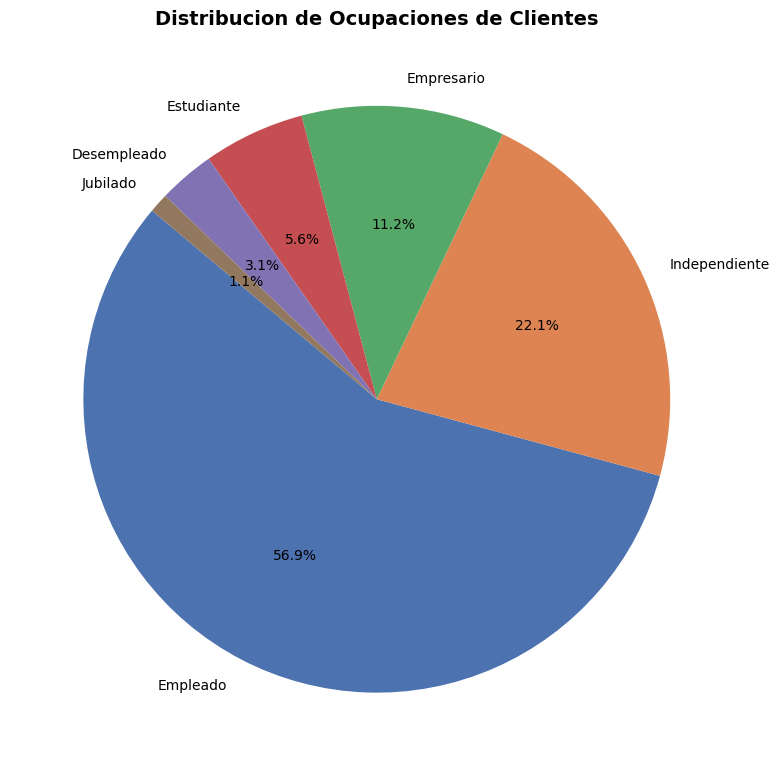

In [73]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data/hey_clientes.csv')

ocupaciones = df['ocupacion'].value_counts()

fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(
    ocupaciones.values,
    labels=ocupaciones.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3', '#937860']
)
ax.set_title('Distribucion de Ocupaciones de Clientes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
